# LAB11 -  Saktesia e GPS/GNSS dhe Variacioni i Pozicionit
---
- ##### Tema: **Saktesia e GPS/GNSS dhe Variacioni i Pozicionit**
- ##### Studentja: Artea Zerellari
- ##### Pedagogu: Ervin Kafexhiu
- ##### Data: 03.06.2026
---

# **Qellimi i laboratorit** :

Qellimi i ketij laboratori ishte te studiohej variacioni i pozicionit te matur nga GPS/GNSS i nje smartphone edhe kur telefoni qendron i palevizur. Te dhenat u regjistruan me aplikacionin phyphox dhe u analizuan ne Python per te vleresuar saktesine e matjeve.

**Pajisjet:**

* iPhone
* Laptop me JupyterLab/Python
* Aplikacioni phyphox
* GPS/GNSS i integruar ne telefon

**Struktura e laboratorit:**

Laboratori u nda ne tre eksperimente:

* **Eksperimenti A:** Telefoni i palevizur ne qiell te hapur.
* **Eksperimenti B:** Telefoni i palevizur brenda ose prane nderteses.
* **Eksperimenti C:** Ecje ne nje rruge te shkurter.
---

* **Eksperimenti A - Telefoni i palevizur ne qiell te hapur:**

**Qellimi:**

Te studiohet variacioni i pozicionit GPS kur telefoni qendron i palevizur ne ambient te hapur.

**Procedura:**

Telefoni u vendos ne nje pozicion fiks ne ambient te hapur. Pas stabilizimit te sinjalit GPS u regjistruan te dhenat per disa minuta me aplikacionin phyphox. Te dhenat u eksportuan ne format CSV.

**Skedari i perdorur:**

data/gps_outdoor_stationary.csv
---

---
* **Eksperimenti B - Telefoni i palevizur brenda/prane nderteses:**

**Qellimi:**

Te krahasohet saktesia e GPS ne kushte me pengesa ndaj matjes ne ambient te hapur.

**Procedura:**

Telefoni u vendos ne nje pozicion fiks brenda ose prane nderteses dhe u regjistruan te dhenat GPS per disa minuta.

**Skedari i perdorur:**

data/gps_indoor.csv
---

---
* **Eksperimenti C - Ecje:**

**Qellimi:**

Te analizohet trajektorja e matur nga GPS gjate levizjes.

**Procedura:**

U realizua nje ecje ne nje rruge te shkurter me shpejtesi pothuajse konstante. Pozicioni GPS u regjistrua gjate gjithe levizjes.

**Skedari i perdorur:**

data/gps_walk.csv
---

---

# **Pergatitja e te dhenave ne Python** :

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("gps_outdoor_stationary.csv")

lat_col = "Latitude (°)"
lon_col = "Longitude (°)"
time_col = "Time (s)"

lat = pd.to_numeric(df[lat_col], errors="coerce")
lon = pd.to_numeric(df[lon_col], errors="coerce")

mask = ~(lat.isna() | lon.isna())

lat = lat[mask].to_numpy()
lon = lon[mask].to_numpy()

print("Numri i matjeve:", len(lat))
print("Latitude mesatare:", np.mean(lat))
print("Longitude mesatare:", np.mean(lon))

Numri i matjeve: 39
Latitude mesatare: 41.32345342666666
Longitude mesatare: 19.760678488461544


# **Kovektimi i koordinatave ne metra :**

In [3]:
R = 6371000

lat_rad = np.deg2rad(lat)
lon_rad = np.deg2rad(lon)

lat0 = np.mean(lat_rad)
lon0 = np.mean(lon_rad)

x = R * np.cos(lat0) * (lon_rad - lon0)
y = R * (lat_rad - lat0)

r = np.sqrt(x**2 + y**2)

print("Devijimi standard ne x [m]:", np.std(x, ddof=1))
print("Devijimi standard ne y [m]:", np.std(y, ddof=1))
print("Devijimi radial mesatar [m]:", np.mean(r))
print("Devijimi radial maksimal [m]:", np.max(r))
print("68% e pikave brenda [m]:", np.percentile(r, 68))
print("95% e pikave brenda [m]:", np.percentile(r, 95))

Devijimi standard ne x [m]: 0.577204091781737
Devijimi standard ne y [m]: 0.3342419708251863
Devijimi radial mesatar [m]: 0.6529589493700847
Devijimi radial maksimal [m]: 0.7488553660491357
68% e pikave brenda [m]: 0.7488553660491357
95% e pikave brenda [m]: 0.7488553660491357


---
# **GRAFIKET KRYESOR** :

---
## **Shperndarja 2D e Pozicionit GPS :**
**Shpjegim:**
Ky grafik tregon shperndarjen e pozicioneve te matura nga GPS rreth pozicionit mesatar. Edhe pse telefoni ka qene i palevizshem, pikat nuk bien ne te njejtin vend per shkak te pasigurise se matjes GPS.

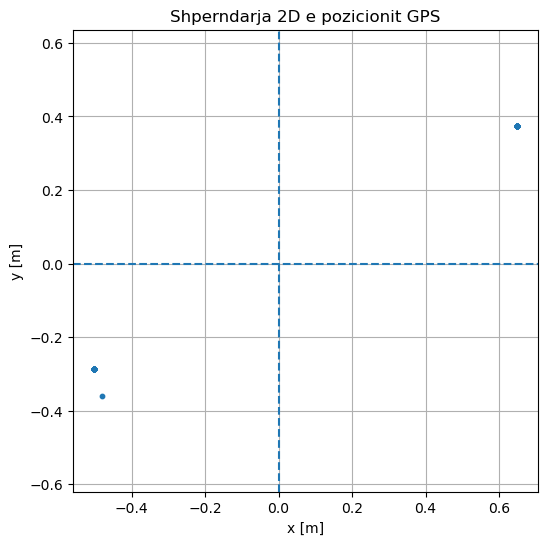

In [5]:
plt.figure(figsize=(6,6))
plt.scatter(x, y, s=10)

plt.axhline(0, linestyle="--")
plt.axvline(0, linestyle="--")

plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.title("Shperndarja 2D e pozicionit GPS")

plt.axis("equal")
plt.grid(True)
plt.show()

---
## **Histogrami i Devijimit Radial :**
**Shpjegim:**
Histogrami paraqet sa shpesh pozicioni i matur ndodhet ne nje distance te caktuar nga pozicioni mesatar. Ai tregon shperndarjen e gabimit radial gjate matjes

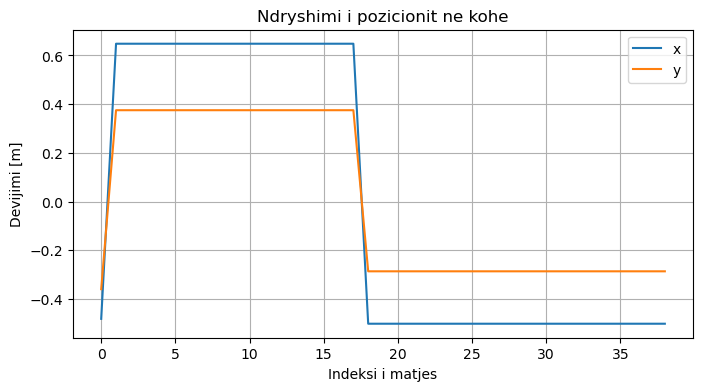

In [6]:
plt.figure(figsize=(8,4))

plt.plot(x, label="x")
plt.plot(y, label="y")

plt.xlabel("Indeksi i matjes")
plt.ylabel("Devijimi [m]")
plt.title("Ndryshimi i pozicionit ne kohe")

plt.legend()
plt.grid(True)
plt.show()

---
## **Ndryshimi i Pozicionit ne Kohe :**
**Shpjegim:**
Ky grafik tregon ndryshimin e koordinatave x dhe y gjate kohes. Ai ndihmon ne identifikimin e drift-it ose luhatjeve te pozicionit te raportuar nga GPS.

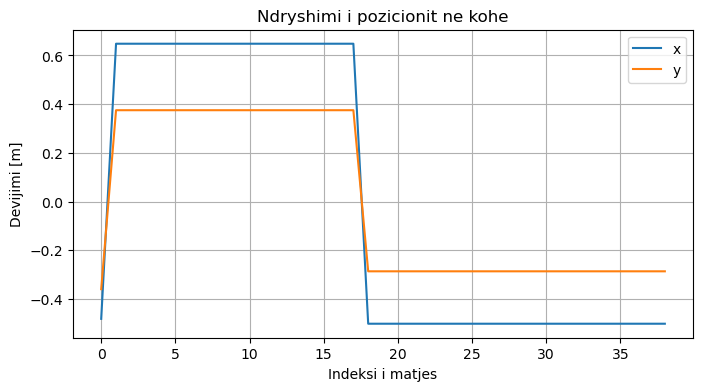

In [7]:
plt.figure(figsize=(8,4))

plt.plot(x, label="x")
plt.plot(y, label="y")

plt.xlabel("Indeksi i matjes")
plt.ylabel("Devijimi [m]")
plt.title("Ndryshimi i pozicionit ne kohe")

plt.legend()
plt.grid(True)
plt.show()

---
# **Krahasimi i Dy Kushteve (Outdoor dhe Indoor) :**
**Shpjegim:**
Grafiku krahason shperndarjen e gabimit radial ne dy kushte te ndryshme matjeje. Ne pergjithesi, matjet ne ambiente te brendshme ose prane pengesave paraqesin devijime me te medha se matjet ne qiell te hapur.

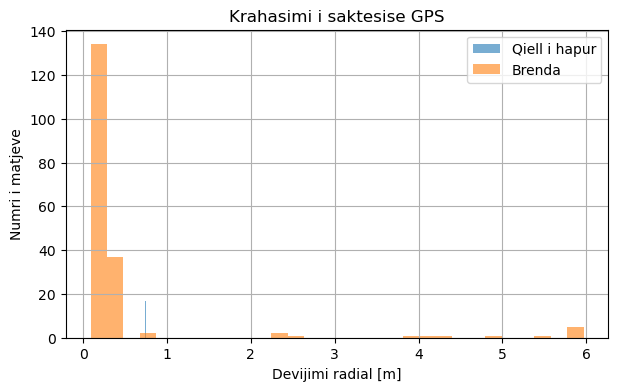

In [10]:
def load_gps_csv(filename):
    df = pd.read_csv(filename)

    lat = pd.to_numeric(df["Latitude (°)"], errors="coerce")
    lon = pd.to_numeric(df["Longitude (°)"], errors="coerce")

    mask = ~(lat.isna() | lon.isna())

    lat = lat[mask].to_numpy()
    lon = lon[mask].to_numpy()

    R = 6371000

    lat_rad = np.deg2rad(lat)
    lon_rad = np.deg2rad(lon)

    lat0 = np.mean(lat_rad)
    lon0 = np.mean(lon_rad)

    x = R * np.cos(lat0) * (lon_rad - lon0)
    y = R * (lat_rad - lat0)

    r = np.sqrt(x**2 + y**2)

    return r

r1 = load_gps_csv("gps_outdoor_stationary.csv")
r2 = load_gps_csv("gps_indoor.csv")

plt.figure(figsize=(7,4))

plt.hist(r1, bins=30, alpha=0.6, label="Qiell i hapur")
plt.hist(r2, bins=30, alpha=0.6, label="Brenda")

plt.xlabel("Devijimi radial [m]")
plt.ylabel("Numri i matjeve")
plt.title("Krahasimi i saktesise GPS")

plt.legend()
plt.grid(True)
plt.show()

---
# **Diskutim :**

Rezultatet tregojne se pozicioni GPS nuk mbetet plotesisht konstant edhe kur telefoni qendron i palevizur. Pikat formojne nje shperndarje rreth pozicionit mesatar, duke treguar variacionin normal te matjes.

Saktesia ne ambient te hapur rezultoi me e mire se ne kushte me pengesa. Prania e ndertesave ose pengesave te tjera ndikon ne cilesine e sinjalit dhe rrit devijimin e matjeve.

Nga grafiket verehen luhatje te vazhdueshme te pozicionit, por pa ndryshime te medha te papritura. Kjo tregon se GPS duhet trajtuar si nje instrument mates me pasiguri dhe jo si nje burim koordinatash perfekte.

---
# **Pergjigje per pyetjet e analizes :**

1. Pse duhen të paktën katër satelitë për të përcaktuar pozicionin dhe kohën?
2. Pse pozicioni ndryshon edhe kur telefoni është i palëvizur?
3. Cili është ndryshimi midis saktësisë dhe precizionit në këtë eksperiment?
4. Pse sinjali GPS përkeqësohet pranë ndërtesave?
5. Çfarë kuptimi ka $r_{95}$?
6. A është mesatarja e pozicioneve gjithmonë pozicioni “i vërtetë”? Pse?
7. Çfarë do të ndryshonte nëse do të përdornim një marrës GNSS profesional me RTK?
---
1. Nevojiten te pakten kater satelite per te percaktuar pozicionin tredimensional dhe per te korrigjuar gabimin e ores se marresit.
2. Pozicioni ndryshon edhe kur telefoni eshte i palevizur per shkak te zhurmes se matjes, atmosferes dhe reflektimeve te sinjalit.
3. Saktesia tregon sa afer pozicionit real jane matjet, ndersa precizioni tregon sa afer njera-tjetres jane matjet.
4. Sinjali GPS perkeqesohet prane ndertesave sepse sinjalet bllokohen ose reflektohen.
5. $r_{95}$ paraqet rrezen brenda se ciles bien 95% e matjeve.
6. Mesatarja nuk eshte gjithmone pozicioni i vertete sepse mund te ekzistojne gabime sistematike.
7. Nese do te perdorej nje marrës GNSS profesional me RTK, saktesia do te ishte shume me e larte dhe gabimi do te ishte dukshem me i vogel.

---